Sales Summary:

   product  total_quantity  total_revenue
0   Apples              30           15.0
1  Bananas              25            7.5
2  Oranges              13            9.1


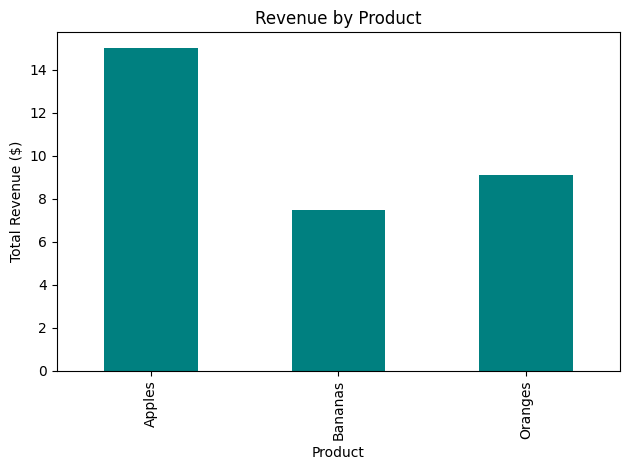

   product  total_qty  revenue
0   Apples         30     15.0
1  Bananas         25      7.5
2  Oranges         13      9.1


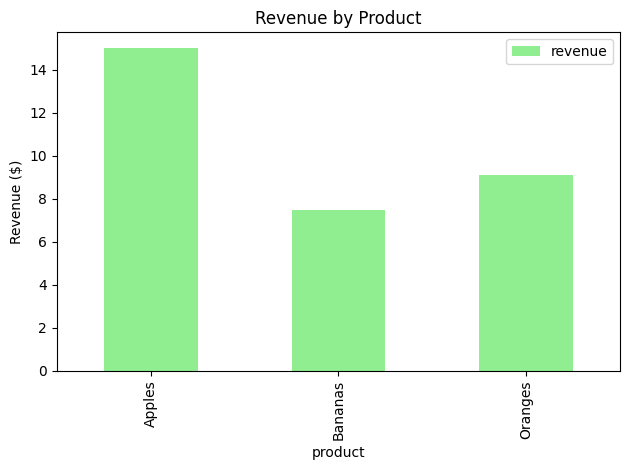

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to (or create) the SQLite database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create sales table
cursor.execute("""
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
""")
conn.commit()

# Insert sample data (run once)
cursor.execute("SELECT COUNT(*) FROM sales")
if cursor.fetchone()[0] == 0:
    sample_data = [
        ('Apples', 10, 0.5),
        ('Apples', 20, 0.5),
        ('Bananas', 15, 0.3),
        ('Oranges', 8, 0.7),
        ('Bananas', 10, 0.3),
        ('Oranges', 5, 0.7)
    ]
    cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
    conn.commit()

# Query for total quantity and revenue by product
query = """
SELECT
    product,
    SUM(quantity) AS total_quantity,
    ROUND(SUM(quantity * price), 2) AS total_revenue
FROM sales
GROUP BY product
"""
df = pd.read_sql_query(query, conn)

# Display query result
print("Sales Summary:\n")
print(df)

# Plot revenue as a bar chart
df.plot(kind='bar', x='product', y='total_revenue', color='teal', legend=False)
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()
plt.savefig("sales_summary_chart.png")  # Optional: save as image
plt.show()

# Close connection
conn.close()
